In [ ]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
print("Pandas version: ",(pd.__version__))
print("SQLite3 version: ",(sqlite3.version))


Pandas version:  2.2.2
SQLite3 version:  2.6.0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df=pd.read_csv('student_performance.csv')
print("dataset loaded: ",df.shape)
print("columns: ",df.columns.tolist())
print("\n first three rows")
df.head(3)


dataset loaded:  (30, 13)
columns:  ['student_id', 'name', 'age', 'gender', 'department', 'semester', 'math_score', 'science_score', 'english_score', 'programming_score', 'attendance_percentage', 'city', 'admission_year']

 first three rows


,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023


In [13]:
conn=sqlite3.connect('college.db')
#conn=our connection to the database
#college.db=the file will be created in colab's filesystem
#if college.db aldready exits it will create new file with same name
cursor=conn.cursor()

In [14]:
cursor = conn.cursor()
df.to_sql('students',conn,if_exists='replace',index=False)
cursor.execute("SELECT COUNT(*) FROM students")
count=cursor.fetchone()[0]
print("Number of rows inserted into 'students' table",count)

NameError: name 'df' is not defined

In [ ]:
cursor.execute("pragma table_info(students)")
columns_info=cursor.fetchall()
#fetchall retrieve all results rows(not just one)
print("table structure of students: ")
print(f"{'column name':<25}{'data type':<12}")
print("-"*45)
for col in columns_info:
  print(f"{col[1]:<25}{col[2]:<12}")

table structure of students: 
column name              data type   
---------------------------------------------
student_id               INTEGER     
name                     TEXT        
age                      INTEGER     
gender                   TEXT        
department               TEXT        
semester                 INTEGER     
math_score               INTEGER     
science_score            INTEGER     
english_score            INTEGER     
programming_score        INTEGER     
attendance_percentage    INTEGER     
city                     TEXT        
admission_year           INTEGER     


the standard SQL query pattern

SELECT column1,column2
FROM table_name
WHERE condition
GROUP BY column
HAVING group_condition
ORDER_BY column DESC
LIMIT 10;

In [4]:
def run_query(sql, description=""):
    """Runs a SQL query and returns results as a pandas dataframe

    Parameters:
    ----------------
    sql : str
        SQL query string
    description : str
        Label to print above the results

    Returns:
    ----------------
    Pandas DataFrame containing the query results
    """

    if description:
        print(f"\n{'='*55}")
        print(description)
        print(f"{'='*55}")

    result = pd.read_sql_query(sql, conn)
    print(result.to_string(index=False))

    return result


print("Helper function 'run_query' defined successfully")
print("Usage: run_query(sql_string, description)")

Helper function 'run_query' defined successfully
Usage: run_query(sql_string, description)


# practice questions
1.total number of students
2.display all column names and data types using PRAGMA
3.show first 5 rows from student table
4.display students with marks greater than 80
5.count number of male and female students

In [ ]:
query1="""select student_id,name,department,math_score,attendance_percentage from students limit 10"""
result1=run_query(query1,"first 10 students")



first 10 students
 student_id         name       department  math_score  attendance_percentage
       1001 Aarav Sharma Computer Science          85                     92
       1002  Priya Patel Computer Science          76                     87
       1003  Rohit Verma      Electronics          65                     78
       1004  Sneha Reddy       Mechanical          70                     95
       1005   Arjun Nair Computer Science          92                     90
       1006  Meera Joshi      Electronics          58                     72
       1007  Kiran Kumar            Civil          73                     85
       1008  Divya Singh Computer Science          88                     96
       1009 Rahul Mishra       Mechanical          62                     68
       1010   Ananya Das Computer Science          95                     98


In [ ]:
query2="""select name,department,math_score from students order by math_score desc limit 5"""
result2=run_query(query2,"top 5 performers in maths")


top 5 performers in maths
          name       department  math_score
    Ananya Das Computer Science          95
   Tanvi Mehta Computer Science          93
    Arjun Nair Computer Science          92
Akanksha Yadav Computer Science          91
Swati Kulkarni Computer Science          90


In [ ]:
#where condition
query3="""select name,math_score,programming_score,attendance_percentage from students
where department='Computer Science' order by programming_score desc"""

result3=run_query(query3,"top programming score in cs")


top programming score in cs
          name  math_score  programming_score  attendance_percentage
    Ananya Das          95                 97                     98
   Tanvi Mehta          93                 96                     97
    Arjun Nair          92                 95                     90
Akanksha Yadav          91                 94                     95
   Divya Singh          88                 93                     96
Swati Kulkarni          90                 92                     94
  Aarav Sharma          85                 91                     92
     Amit Bose          86                 89                     91
    Suresh Rao          83                 88                     88
 Gaurav Shukla          84                 87                     87
  Nisha Kapoor          79                 83                     89
   Priya Patel          76                 79                     87
   Ajay Tiwari          71                 76                     75


In [ ]:
query4="""select name,department,attendance_percentage from students
where attendance_percentage>90
and department!='Civil'
order by attendance_percentage desc"""

result4=run_query(query4,"students with high attendance except civil")


students with high attendance except civil
          name       department  attendance_percentage
    Ananya Das Computer Science                     98
   Tanvi Mehta Computer Science                     97
   Divya Singh Computer Science                     96
   Sneha Reddy       Mechanical                     95
Akanksha Yadav Computer Science                     95
Swati Kulkarni Computer Science                     94
  Ritu Agarwal      Electronics                     93
  Aarav Sharma Computer Science                     92
 Kavya Nambiar       Mechanical                     91
     Amit Bose Computer Science                     91


In [ ]:
query5="""select department,count(*) as num_students ,round(avg(math_score),2)as math_avg,
round(avg(programming_score),2) as prog_avg,
round(avg(science_score),2) as science_avg,
round(avg(english_score),2) as english_avg,
round(avg(attendance_percentage),2) as attendance_avg
from students
group by department
order by math_avg desc"""

result5=run_query(query5,"department wise average scores")


department wise average scores
      department  num_students  math_avg  prog_avg  science_avg  english_avg  attendance_avg
Computer Science            13     85.62     89.23        84.46        80.85           90.69
      Mechanical             6     71.00     49.33        76.50        70.50           83.50
     Electronics             6     71.00     61.50        74.17        70.83           80.33
           Civil             5     63.40     40.60        66.60        65.20           74.60


In [ ]:
query6="""select department,round(avg(math_score),2) as math_avg,
count(*)as total_students from students
group by department
having(math_avg>70)
order by math_avg desc"""

result6=run_query(query6,"average math score above 70")


average math score above 70
      department  math_avg  total_students
Computer Science     85.62              13
      Mechanical     71.00               6
     Electronics     71.00               6


In [ ]:
query7="""select gender,count(*) as tot_students ,round(avg(math_score),2)as math_avg,
round(avg(programming_score),2) as prog_avg,
round(avg(science_score),2) as science_avg,
round(avg(english_score),2) as english_avg,
round(avg(attendance_percentage),2) as attendance_avg
from students
group by gender
"""

result5=run_query(query7,"Genderwise average score")


Genderwise average score
gender  tot_students  math_avg  prog_avg  science_avg  english_avg  attendance_avg
Female            15     78.47      70.2        81.20        80.80           88.53
  Male            15     73.67      65.0        74.47        67.53           80.47


In [ ]:
query8="""select name,department,math_score+programming_score+science_score+english_score as total_score,
attendance_percentage from students order by total_score desc limit 10"""
result8=run_query(query8,"top 10 performers in terms of total score")



top 10 performers in terms of total score
          name       department  total_score  attendance_percentage
    Ananya Das Computer Science          371                     98
   Tanvi Mehta Computer Science          367                     97
Akanksha Yadav Computer Science          365                     95
    Arjun Nair Computer Science          356                     90
   Divya Singh Computer Science          356                     96
Swati Kulkarni Computer Science          354                     94
     Amit Bose Computer Science          336                     91
    Suresh Rao Computer Science          334                     88
  Nisha Kapoor Computer Science          327                     89
  Aarav Sharma Computer Science          326                     92


In [ ]:
#create a department table for join demonstration
dept_data={
    'dept_code':['CS','EC','ME','CV'],
    'dept_name':['Computer Science','Electronics','Mechanical','Civil'],
    'hod_name':['Dr.Sumathi','Dr.vivek kumar','Dr.Gnanavel','Dr.Mohana'],
    'established_year':[1980,1985,1990,1995]
}
dept_df=pd.DataFrame(dept_data)
dept_df.to_sql('departments',conn,if_exists='replace',index=False)
print("created department table")
print(dept_df.to_string(index=False))
dept_map={'CS':'Computer Science','EC':'Electronics','ME':'Mechanical','CV':'Civil'}
df['department']=df['department'].map(dept_map)




created department table
dept_code        dept_name       hod_name  established_year
       CS Computer Science     Dr.Sumathi              1980
       EC      Electronics Dr.vivek kumar              1985
       ME       Mechanical    Dr.Gnanavel              1990
       CV            Civil      Dr.Mohana              1995


In [ ]:
query_join = """
SELECT
    s.name,
    s.math_score,
    d.dept_name,
    d.hod_name,
    d.established_year
FROM students AS s
INNER JOIN departments AS d
ON s.department = d.dept_name
ORDER BY s.math_score DESC
LIMIT 8
"""

result_join = run_query(query_join, "Join: Students with Department details (INNER JOIN)")


Join: Students with Department details (INNER JOIN)
          name  math_score        dept_name       hod_name  established_year
    Ananya Das          95 Computer Science     Dr.Sumathi              1980
   Tanvi Mehta          93 Computer Science     Dr.Sumathi              1980
    Arjun Nair          92 Computer Science     Dr.Sumathi              1980
Akanksha Yadav          91 Computer Science     Dr.Sumathi              1980
Swati Kulkarni          90 Computer Science     Dr.Sumathi              1980
   Divya Singh          88 Computer Science     Dr.Sumathi              1980
  Ritu Agarwal          87      Electronics Dr.vivek kumar              1985
     Amit Bose          86 Computer Science     Dr.Sumathi              1980


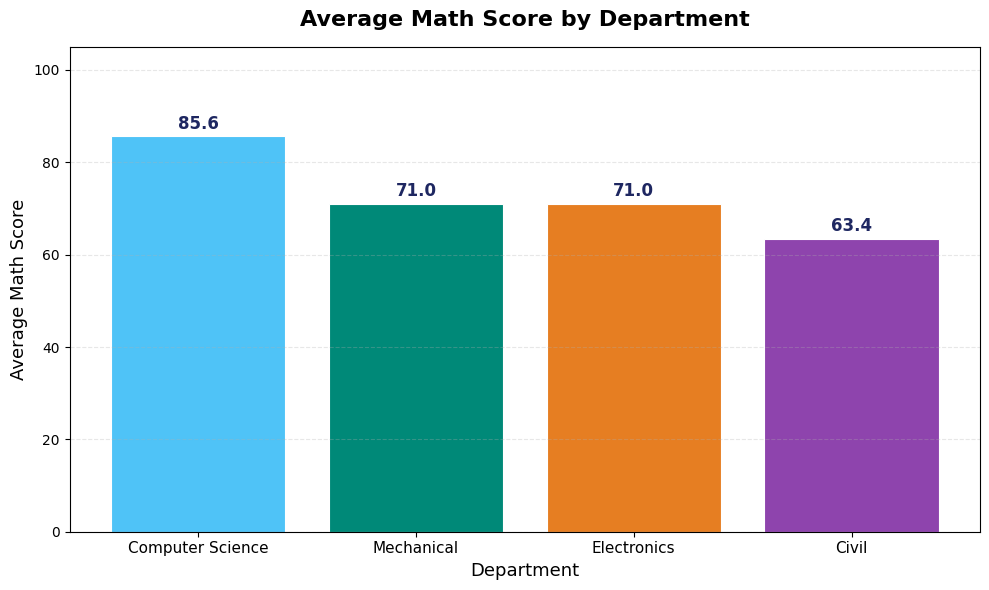

In [ ]:
chart1_sql = """
SELECT
    department,
    ROUND(AVG(math_score),2) AS math_avg
FROM students
GROUP BY department
ORDER BY math_avg DESC
"""

chart1_data = pd.read_sql_query(chart1_sql, conn)

fig, ax = plt.subplots(figsize=(10,6))

bar_colors = ['#4FC3F7', '#008978', '#E67E22', '#8E44AD']

bars = ax.bar(
    chart1_data['department'],
    chart1_data['math_avg'],
    color=bar_colors,
    edgecolor='white',
    linewidth=0.8
)

for bar in bars:
    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.8,
        f'{height:.1f}',
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold',
        color='#1E2761'
    )

ax.set_title(
    'Average Math Score by Department',
    fontsize=16,
    fontweight='bold',
    pad=15
)

ax.set_xlabel('Department', fontsize=13)
ax.set_ylabel('Average Math Score', fontsize=13)

ax.set_ylim(0,105)

ax.tick_params(axis='x', labelsize=11)

ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

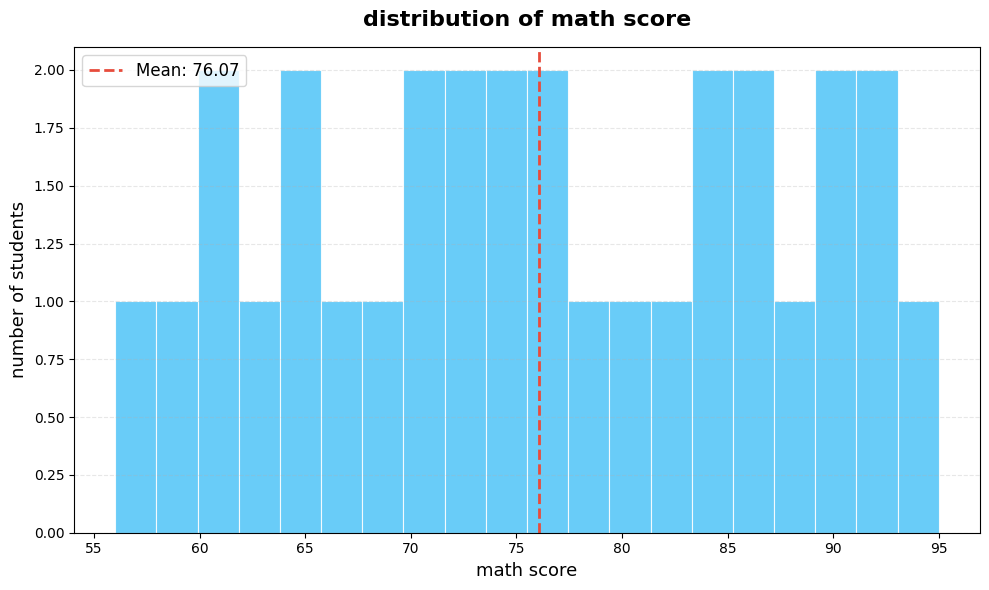

In [ ]:
math_scores=df['math_score'].tolist()
fig,ax=plt.subplots(figsize=(10,6))
n,bins,patches=ax.hist(
    math_scores,
    bins=20,
    color='#4FC3F7',
    edgecolor='white',
    linewidth=0.8,
    alpha=0.85
)

mean_score=sum(math_scores)/len(math_scores)
ax.axvline(
    x=mean_score,
    color='#E74C3C',
    linestyle='--',
    linewidth=2,
    label=f'Mean: {mean_score:.2f}'
)

ax.set_title('distribution of math score',fontsize=16,fontweight='bold',pad=15)
ax.set_xlabel('math score',fontsize=13)
ax.set_ylabel('number of students',fontsize=13)
ax.legend(fontsize=12)
ax.grid(axis='y',alpha=0.3,linestyle='--')
plt.tight_layout()
plt.show()

In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

df = pd.DataFrame({
    'Category': np.random.choice(['A', 'B', 'C','D'], 100),
    'Value': np.random.randint(10,100,100),
    'score': np.random.randint(10,100,100)
})

print(df.head())

  Category  Value  score
0        D     26     60
1        D     70     98
2        C     77     22
3        B     58     68
4        D     57     72


In [82]:
import plotly.express as px

category_counts = df['Category'].value_counts().reset_index()

category_counts.columns = ['Category', 'Count']

fig = px.bar(
    category_counts,
    x='Category',
    y='Count',
    color='Category',
    title='Interactive Category Distribution',
    text='Count'
)

fig.update_traces(textposition='outside')

fig.update_layout(
    xaxis_title='Category',
    yaxis_title='Count'
)

fig.show()

#Practice questions

In [25]:
import sqlite3
import pandas as pd

conn=sqlite3.connect('college.db')
cursor=conn.cursor()

In [28]:
query = """
SELECT name FROM sqlite_master
WHERE type='table'
"""

df = pd.read_sql_query(query, conn)

print(df)

       name
0  students


In [31]:
students_data = [
    ('Ravi', 'Male', 'CSE', 85, 90, 88, 175),
    ('Priya', 'Female', 'IT', 92, 95, 91, 187),
    ('Arun', 'Male', 'ECE', 78, 80, 84, 158),
    ('Divya', 'Female', 'CSE', 88, 93, 89, 181),
    ('Karthik', 'Male', 'IT', 75, 70, 82, 145),
    ('Sneha', 'Female', 'ECE', 95, 97, 96, 192)
]

cursor.executemany("""
INSERT INTO students VALUES (?, ?, ?, ?, ?, ?, ?)
""", students_data)

conn.commit()

print("Data inserted successfully")


Data inserted successfully


In [32]:
query = """
SELECT AVG(programming_score) AS avg_programming_score
FROM students
WHERE gender = 'Female'
"""

df = pd.read_sql_query(query, conn)

print(df)

   avg_programming_score
0                   95.0


In [33]:
query = """
SELECT name, attendance_percentage
FROM students
WHERE attendance_percentage > 85
"""

df = pd.read_sql_query(query, conn)

print(df)

    name  attendance_percentage
0   Ravi                   88.0
1  Priya                   91.0
2  Divya                   89.0
3  Sneha                   96.0


In [34]:
query = """
SELECT department,
AVG(attendance_percentage) AS avg_attendance
FROM students
GROUP BY department
HAVING AVG(attendance_percentage) > 85
"""

df = pd.read_sql_query(query, conn)

print(df)

  department  avg_attendance
0        CSE            88.5
1        ECE            90.0
2         IT            86.5


In [35]:
query = "SELECT * FROM students"

# execute query and store result
df = pd.read_sql_query(query, conn)

# display dataframe
print(df)

      name  gender department  math_score  programming_score  \
0     Ravi    Male        CSE          85                 90   
1    Priya  Female         IT          92                 95   
2     Arun    Male        ECE          78                 80   
3    Divya  Female        CSE          88                 93   
4  Karthik    Male         IT          75                 70   
5    Sneha  Female        ECE          95                 97   

   attendance_percentage  total_score  
0                   88.0          175  
1                   91.0          187  
2                   84.0          158  
3                   89.0          181  
4                   82.0          145  
5                   96.0          192  


In [37]:
import matplotlib.pyplot as plt
import pandas as pd

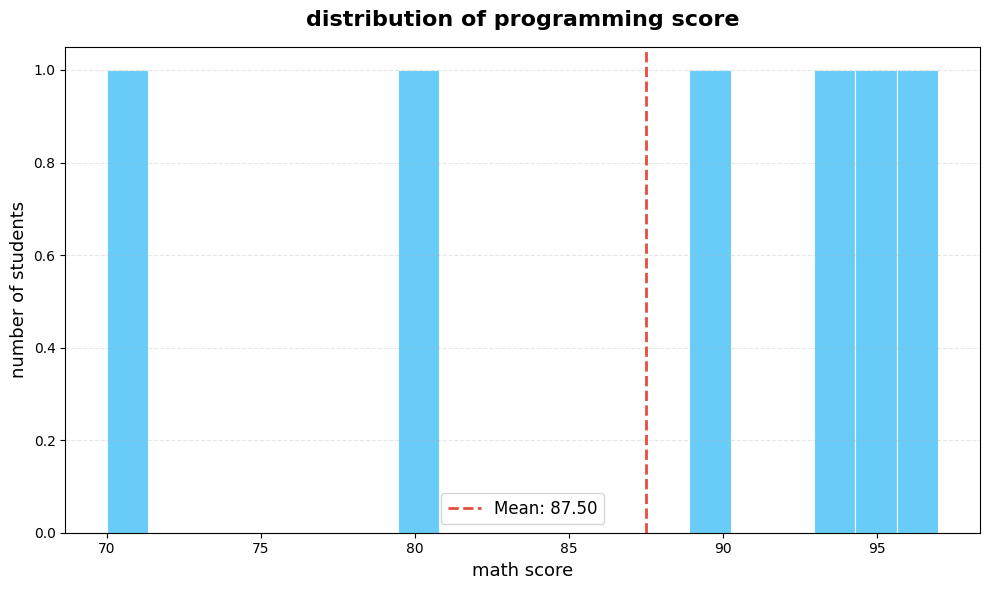

In [38]:
programming_scores=df['programming_score'].tolist()
fig,ax=plt.subplots(figsize=(10,6))
n,bins,patches=ax.hist(
    programming_scores,
    bins=20,
    color='#4FC3F7',
    edgecolor='white',
    linewidth=0.8,
    alpha=0.85
)

mean_score=sum(programming_scores)/len(programming_scores)
ax.axvline(
    x=mean_score,
    color='#E74C3C',
    linestyle='--',
    linewidth=2,
    label=f'Mean: {mean_score:.2f}'
)

ax.set_title('distribution of programming score',fontsize=16,fontweight='bold',pad=15)
ax.set_xlabel('math score',fontsize=13)
ax.set_ylabel('number of students',fontsize=13)
ax.legend(fontsize=12)
ax.grid(axis='y',alpha=0.3,linestyle='--')
plt.tight_layout()
plt.show()

Pandas Version: 2.2.2
SQLite3 version: 2.6.0
Dataset loaded succesfully

Task1:Average Math Score by female students
gender  math_avg
Female     78.47

Task 2 : Example of WHERE and HAVING Clause
      department  avg_math_score
Computer Science           86.83
     Electronics           76.00
      Mechanical           72.80

Task 3 : Departments with Average Attendance Above 85%
      department  avg_attendance
Computer Science           90.69

pd.read_sql_query() executes an SQL query
and returns the result as a Pandas DataFrame.

Syntax:
pd.read_sql_query(sql_query, connection)

Arguments Required:
1. SQL Query
2. Database Connection



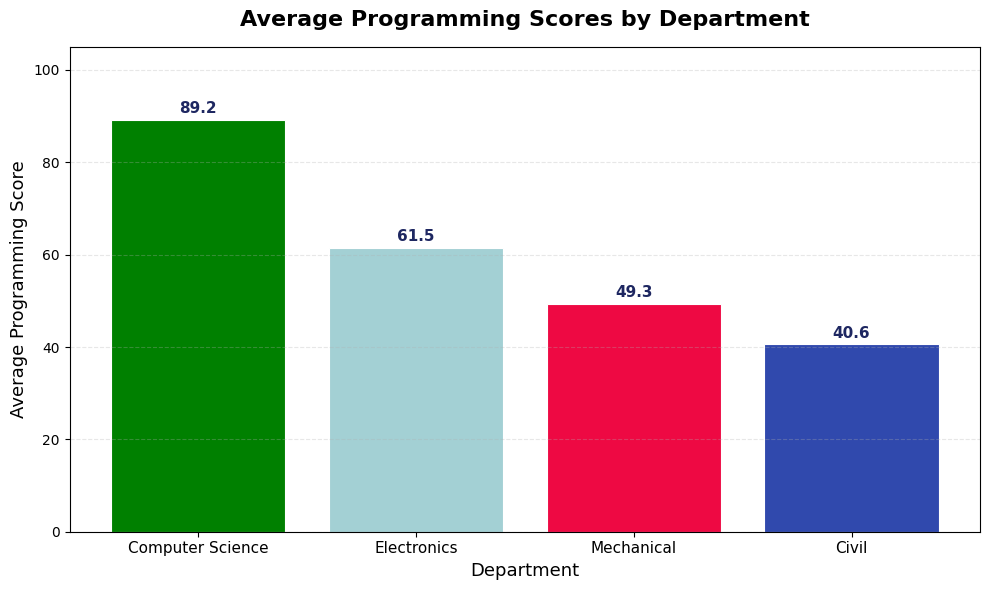

In [39]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
print("Pandas Version:",(pd.__version__))
print("SQLite3 version:",sqlite3.version)
df=pd.read_csv('student_performance.csv')
print("Dataset loaded succesfully")

#CONNECTING TO SQLITE DATABSE
conn=sqlite3.connect('college.db')

df.to_sql('students',conn,if_exists='replace',index=False)
def run_query(sql,description=""):
  if description:
    print(f"\n{'='*55}")
    print(description)
    print(f"{'='*55}")
  result=pd.read_sql_query(sql,conn)
  print(result.to_string(index=False))
  return result

  #Task1
query1 = """select gender, round(avg(math_score), 2) as math_avg from students where
gender = 'Female' group by  gender """
result1=run_query(query1,"Task1:Average Math Score by female students")

#Task2
query2 = """
SELECT
    department,
    ROUND(AVG(math_score), 2) AS avg_math_score
FROM students
WHERE attendance_percentage > 75
GROUP BY department
HAVING AVG(math_score) > 70
"""

result2 = run_query(
    query2,
    "Task 2 : Example of WHERE and HAVING Clause"
)

#Task3
query3 = """
SELECT
    department,
    ROUND(AVG(attendance_percentage), 2) AS avg_attendance
FROM students
GROUP BY department
HAVING AVG(attendance_percentage) > 85
"""

result3 = run_query(
    query3,
    "Task 3 : Departments with Average Attendance Above 85%"
)

#task4
print("""
pd.read_sql_query() executes an SQL query
and returns the result as a Pandas DataFrame.

Syntax:
pd.read_sql_query(sql_query, connection)

Arguments Required:
1. SQL Query
2. Database Connection
""")

#Task5
query5 = """
SELECT
    department,
    ROUND(AVG(programming_score), 2) AS avg_programming_score
FROM students
GROUP BY department
ORDER BY avg_programming_score DESC
"""

chart5_data = pd.read_sql_query(query5, conn)

# Create Figure
fig, ax = plt.subplots(figsize=(10, 6))

# Colors
bar_colors = ['#008000', '#A3D0D4', '#EE0943',
              '#3049AD', '#FFA500', '#800080']

# Bar Chart
bars = ax.bar(
    chart5_data['department'],
    chart5_data['avg_programming_score'],
    color=bar_colors,
    edgecolor='white',
    linewidth=0.8
)

# Value Labels
for bar in bars:
    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.8,
        f'{height:.1f}',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold',
        color='#1E2761'
    )

# Title and Labels
ax.set_title(
    'Average Programming Scores by Department',
    fontsize=16,
    fontweight='bold',
    pad=15
)

ax.set_xlabel('Department', fontsize=13)
ax.set_ylabel('Average Programming Score', fontsize=13)

# Limits and Grid
ax.set_ylim(0, 105)

ax.grid(
    axis='y',
    alpha=0.3,
    linestyle='--'
)

ax.tick_params(axis='x', labelsize=11)

plt.tight_layout()
plt.show()

#MINI PROJECT — Student Performance Dashboard

In [40]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
print("Pandas Version:",(pd.__version__))
print("SQLite3 version:",sqlite3.version)
df=pd.read_csv('student_performance.csv')
print("Dataset loaded succesfully")

#CONNECTING TO SQLITE DATABSE
conn=sqlite3.connect('college.db')

df.to_sql('students',conn,if_exists='replace',index=False)
def run_query(sql,description=""):
  if description:
    print(f"\n{"="*55}")
    print(description)
    print(f"{"="*55}")
  result=pd.read_sql_query(sql,conn)
  print(result.to_string(index=False))
  return result

  #Task 1
#Average Math Score by department
query1="""select department , round(avg(math_score),1) as math_avg from students
group by department order by
math_avg desc"""
result1=run_query(query1,"Task1:Average Math Score by department")


#Task 2
#total number of students in each department
query2="""select department,count(*) as total_students from students group by department"""
result2=run_query(query2,"Task 2: Total Number of students in each department")

#Task3
#Calculate total score
query3="""select name,((math_score+english_score+programming_score+science_score
))as total_score from students order by total_score desc limit 8"""
result3=run_query(query3,"Task 3: Top 8 students with respect to Total Score")

#Task 4
#Average attendance percentage by gender
query4="""select gender ,round(avg(attendance_percentage),1)as avg_attendance from students
group by gender"""
result4=run_query(query4,"Task 4: Average attendance by gender")

Pandas Version: 2.2.2
SQLite3 version: 2.6.0
Dataset loaded succesfully

Task1:Average Math Score by department
      department  math_avg
Computer Science      85.6
      Mechanical      71.0
     Electronics      71.0
           Civil      63.4

Task 2: Total Number of students in each department
      department  total_students
           Civil               5
Computer Science              13
     Electronics               6
      Mechanical               6

Task 3: Top 8 students with respect to Total Score
          name  total_score
    Ananya Das          371
   Tanvi Mehta          367
Akanksha Yadav          365
    Arjun Nair          356
   Divya Singh          356
Swati Kulkarni          354
     Amit Bose          336
    Suresh Rao          334

Task 4: Average attendance by gender
gender  avg_attendance
Female            88.5
  Male            80.5


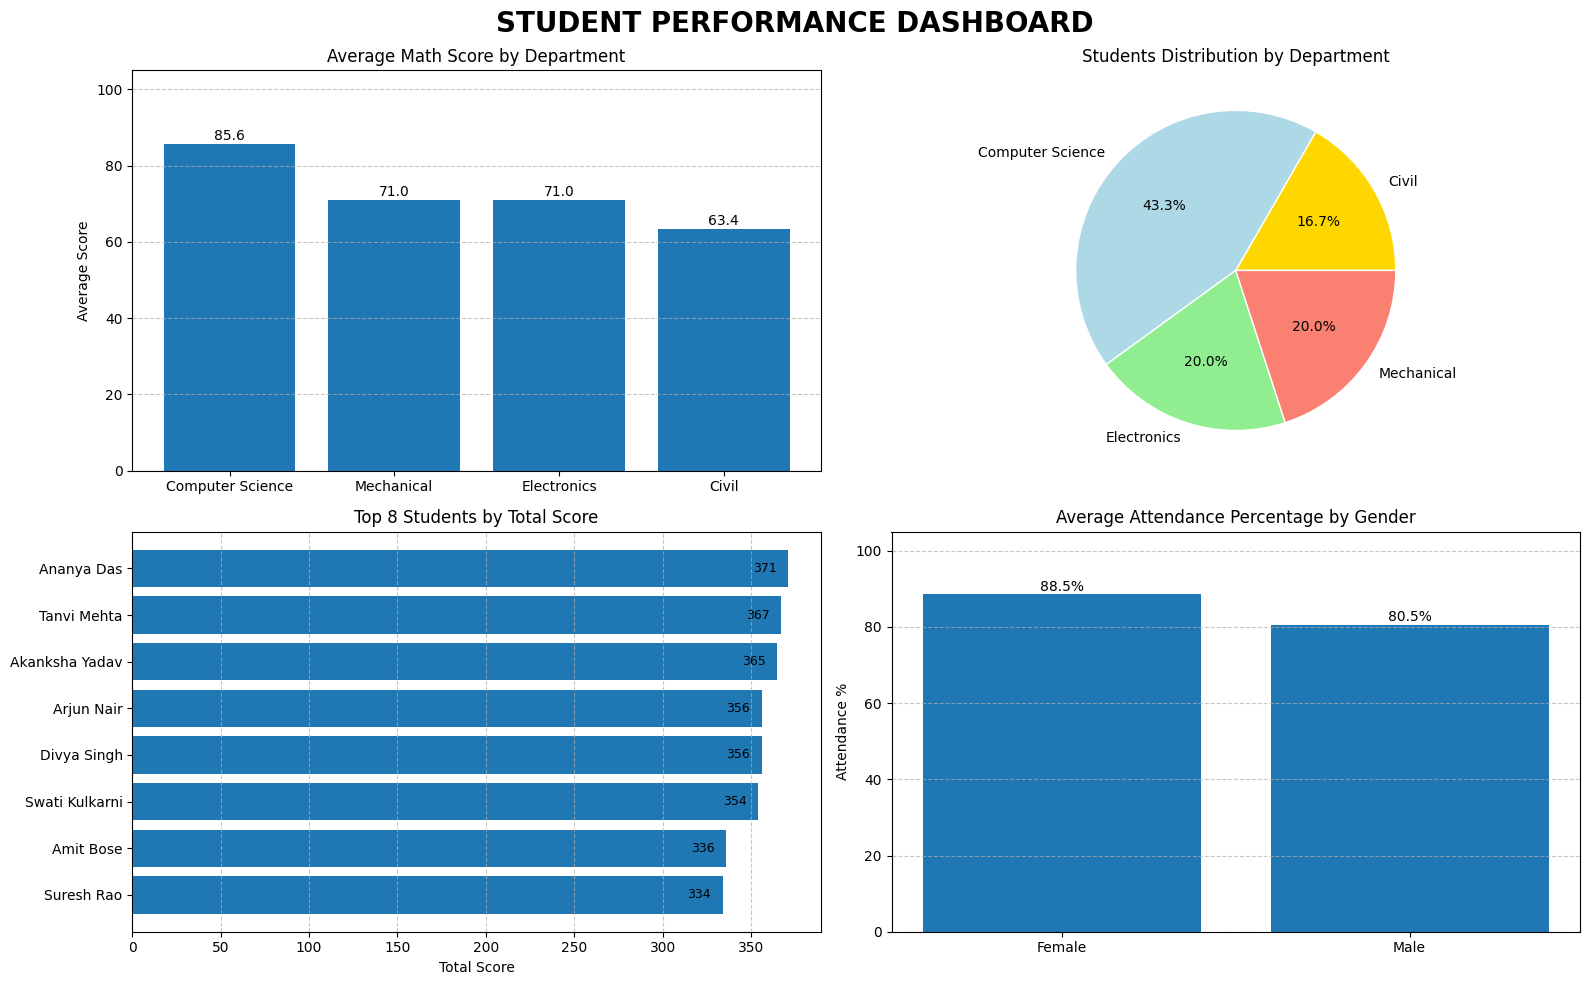


Dashboard saved successfully as 'student_dashboard.png'


In [43]:
# ============================================
# CREATE DASHBOARD USING MATPLOTLIB
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# ============================================
# PANEL 1
# Average Math Score by Department
# ============================================

ax1 = axes[0, 0]

bars1 = ax1.bar(
    result1['department'],
    result1['math_avg']
)

ax1.set_title("Average Math Score by Department")
ax1.set_ylabel("Average Score")
ax1.set_ylim(0, 105)

# Grid Lines
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Value Labels
for bar in bars1:
    height = bar.get_height()

    ax1.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f'{height}',
        ha='center',
        fontsize=10
    )

# ============================================
# PANEL 2
# Pie Chart - Students by Department
# ============================================

ax2 = axes[0, 1]

colors = ['gold', 'lightblue', 'lightgreen', 'salmon', 'violet']

ax2.pie(
    result2['total_students'],
    labels=result2['department'],
    autopct='%1.1f%%',
    colors=colors,
    wedgeprops={'edgecolor': 'white'}
)

ax2.set_title("Students Distribution by Department")

# ============================================
# PANEL 3
# Horizontal Bar Chart - Top 8 Students
# ============================================

ax3 = axes[1, 0]

# Reverse order for highest scorer at top
top_students = result3.iloc[::-1]

bars3 = ax3.barh(
    top_students['name'],
    top_students['total_score']
)

ax3.set_title("Top 8 Students by Total Score")
ax3.set_xlabel("Total Score")

# Grid Lines
ax3.grid(axis='x', linestyle='--', alpha=0.7)

# Labels inside bars
for bar in bars3:

    width = bar.get_width()

    ax3.text(
        width - 20,
        bar.get_y() + bar.get_height()/2,
        f'{width}',
        va='center',
        fontsize=9
    )

# ============================================
# PANEL 4
# Average Attendance by Gender
# ============================================

ax4 = axes[1, 1]

bars4 = ax4.bar(
    result4['gender'],
    result4['avg_attendance']
)

ax4.set_title("Average Attendance Percentage by Gender")
ax4.set_ylabel("Attendance %")
ax4.set_ylim(0, 105)

# Grid Lines
ax4.grid(axis='y', linestyle='--', alpha=0.7)

# Percentage Labels
for bar in bars4:

    height = bar.get_height()

    ax4.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f'{height}%',
        ha='center',
        fontsize=10
    )

# ============================================
# DASHBOARD TITLE
# ============================================

fig.suptitle(
    "STUDENT PERFORMANCE DASHBOARD",
    fontsize=20,
    fontweight='bold'
)

# Proper Spacing
plt.tight_layout()

# ============================================
# SAVE DASHBOARD
# ============================================

plt.savefig(
    "student_dashboard.png",
    dpi=150,
    bbox_inches='tight'
)

# Show Dashboard
plt.show()

# ============================================
# CONFIRMATION MESSAGE
# ============================================

print("\nDashboard saved successfully as 'student_dashboard.png'")